# Naive Bayes - Detección de SMS Spam

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Supervisado · Clasificación · Naive Bayes

---

### Objetivo

Clasificar mensajes SMS como **spam** o **ham** (legítimo) usando **Naive Bayes Multinomial** sobre el texto vectorizado, y verificar honestamente qué tan fiable es el resultado antes de darlo por bueno.

### Contexto de negocio

**El cliente:** un operador de telefonía que quiere filtrar SMS de phishing y publicidad no deseada antes de que lleguen al usuario.

**El problema:** un filtro que bloquea demasiados mensajes legítimos (falsos positivos) genera quejas y desconfianza; uno que deja pasar spam no sirve para nada. El equilibrio entre precisión y recall importa más que la accuracy global.

**La pregunta:** ¿puede un modelo tan simple como Naive Bayes, entrenado solo con el texto del mensaje, distinguir spam de mensajes legítimos con fiabilidad suficiente para producción?

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND   = '#fbfbfb'
PURPLE       = '#7a7bff'   # único color de énfasis (1 por gráfico)
PURPLE_LIGHT = '#9b9cff'   # EDA de una sola serie (histogramas) -- PURPLE fuerte queda solo para el enfasis
POSITIVE     = '#6b8158'   # exclusivo signo positivo
NEGATIVE     = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR  = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE = '#8f8c9e'   # líneas de contexto (más contraste que NEUTRAL_BAR)
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ lineas de contexto en un mismo grafico
INK          = '#111111'
MUTED        = '#707070'

# Alias de compatibilidad con el resto del notebook
GREEN, RED, GRAY = POSITIVE, NEGATIVE, NEUTRAL_BAR

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga y exploración

In [2]:
df = pd.read_excel("sms_spam.xlsx")

df["Message"] = df["Message"].astype(str)
df["sms_type"] = df["sms_type"].astype(str)
df = df.dropna(subset=["Message", "sms_type"])

print(f"Filas: {df.shape[0]}")
df["sms_type"].value_counts()

Filas: 5572


sms_type
ham     4825
spam     747
Name: count, dtype: int64

**4.825 mensajes ham (86,6%) frente a 747 spam (13,4%)** — un desbalance moderado, típico en detección de spam. No es tan extremo como para necesitar técnicas de rebalanceo (SMOTE, class_weight), pero sí obliga a mirar **precision/recall por clase**, no solo accuracy: un modelo que dijera "todo es ham" ya acertaría el 86,6% de las veces sin detectar ni un solo spam.

### Calidad del dato: mensajes duplicados

Antes de dividir train/test, comprobamos si hay mensajes repetidos — si un mensaje duplicado cae a la vez en train y test, el modelo no está generalizando en esa fila, solo memorizando.

In [3]:
duplicados = df.duplicated(subset=["Message"]).sum()
print(f"Mensajes duplicados: {duplicados} ({duplicados / len(df) * 100:.1f}% del total)")

df = df.drop_duplicates(subset=["Message"])
print(f"Filas tras eliminar duplicados: {len(df)}")

Mensajes duplicados: 403 (7.2% del total)
Filas tras eliminar duplicados: 5169


**403 mensajes duplicados (7,2% del dataset)** — se eliminan antes de dividir train/test. Como se ve más abajo, esto hace que la accuracy "real" sea ligeramente más baja que si se hubiera evaluado con los duplicados presentes (algo esperable: los duplicados inflaban artificialmente el resultado por fuga de datos entre train y test), pero es la medición honesta.

## 3. Train / Test split

In [4]:
X = df["Message"]
y = df["sms_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

## 4. Modelo — CountVectorizer + Naive Bayes

In [5]:
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.9816

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.96      0.89      0.92       131

    accuracy                           0.98      1034
   macro avg       0.97      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



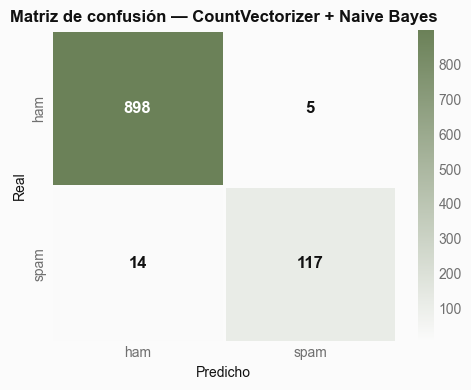

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap=SEQUENTIAL_GREEN,
    linewidths=2, linecolor=BACKGROUND,
    xticklabels=["ham", "spam"], yticklabels=["ham", "spam"], ax=ax,
    annot_kws={"size": 12, "weight": "bold"},
)
color_annotations(ax, cm, threshold=cm.max() * 0.6)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — CountVectorizer + Naive Bayes", fontsize=12, fontweight="bold", color=INK)
plt.tight_layout()
plt.show()

**Accuracy 98,16%**, con **14 spam detectados incorrectamente como ham** (falsos negativos) frente a solo **5 ham marcados como spam** (falsos positivos). El recall de spam es del **89,3% (117 de 131)** — el modelo es conservador: prefiere dejar pasar algún spam antes que bloquear mensajes legítimos, lo cual es la prioridad correcta para un filtro de producción.

## 5. ¿Mejora con TF-IDF?

`CountVectorizer` cuenta apariciones brutas de cada palabra; `TfidfVectorizer` las pondera por rareza (una palabra que aparece en pocos mensajes pesa más que una omnipresente). En clasificación de texto, TF-IDF suele considerarse "superior" por defecto — lo comprobamos en vez de asumirlo.

In [7]:
vectorizer_tfidf = TfidfVectorizer()
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

print(f"Accuracy CountVectorizer: {accuracy_score(y_test, y_pred):.4f}")
print(f"Accuracy TF-IDF:         {accuracy_score(y_test, y_pred_tfidf):.4f}")
print()
print(f"F1-score spam (CountVectorizer): {f1_score(y_test, y_pred, pos_label='spam'):.4f}")
print(f"F1-score spam (TF-IDF):          {f1_score(y_test, y_pred_tfidf, pos_label='spam'):.4f}")
print()
print("Classification report (TF-IDF):")
print(classification_report(y_test, y_pred_tfidf))

Accuracy CountVectorizer: 0.9816
Accuracy TF-IDF:         0.9526

F1-score spam (CountVectorizer): 0.9249
F1-score spam (TF-IDF):          0.7700

Classification report (TF-IDF):
              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       903
        spam       1.00      0.63      0.77       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.96      0.95      0.95      1034



**TF-IDF empeora el modelo**, y no por poco: accuracy 95,26% frente a 98,16%, y el F1-score de spam cae de 0,92 a 0,77. La causa es el recall de spam, que se desploma a la mitad de los casos detectados — TF-IDF **penaliza** precisamente las palabras que más se repiten dentro del spam ("claim", "prize", "www", "150p"...) por considerarlas "poco informativas al ser comunes", cuando en este problema son la señal más fuerte que existe. Para detectar spam por palabras-gancho repetidas, contar apariciones brutas funciona mejor que ponderar por rareza — la lección no es "TF-IDF es peor", es que **la técnica de vectorización "más sofisticada" no siempre gana**, y hay que probarla, no asumirla. Nos quedamos con `CountVectorizer`.

## 6. Interpretabilidad — palabras más indicativas

In [8]:
classes = list(model.classes_)
spam_idx = classes.index("spam")
ham_idx = classes.index("ham")

log_ratio = model.feature_log_prob_[spam_idx] - model.feature_log_prob_[ham_idx]
features = np.array(vectorizer.get_feature_names_out())

top_spam = features[np.argsort(log_ratio)[-15:]][::-1]
top_ham = features[np.argsort(log_ratio)[:15]]

print("Palabras más indicativas de SPAM:")
print(list(top_spam))
print()
print("Palabras más indicativas de HAM:")
print(list(top_ham))

Palabras más indicativas de SPAM:
['claim', 'prize', '150p', 'tone', 'co', 'www', '18', '500', 'guaranteed', '1000', 'cs', 'uk', 'awarded', 'ringtone', '150ppm']

Palabras más indicativas de HAM:
['gt', 'lt', 'he', 'lor', 'da', 'she', 'later', 'but', 'really', 'doing', 'ask', 'cos', 'say', 'lol', 'anything']


Las palabras más asociadas a spam son exactamente lo que un analista esperaría de un filtro de calidad: **claim, prize, 150p, guaranteed, awarded, ringtone, 150ppm** — vocabulario de estafas de premios y tonos de móvil de pago por SMS premium, muy característico del dataset (SMS del Reino Unido, años 2000). Las palabras más asociadas a ham son en su mayoría muletillas conversacionales (**lor, da, lol, cos**) propias de mensajes informales entre conocidos. El modelo no ha memorizado mensajes completos: ha aprendido un vocabulario de spam con sentido de negocio real, lo que da confianza en que generalizará a mensajes nuevos con ese mismo tipo de vocabulario.

## 7. Demostración con mensajes nuevos

El notebook original probaba el modelo con un SMS en **español** ("oferta relampago, haz click aqui"). Repetimos esa prueba y añadimos dos mensajes en inglés — el idioma real del entrenamiento — para comparar.

In [9]:
mensajes_nuevos = [
    "oferta relampago, haz click aqui",
    "Congratulations! You have won a FREE ticket, call now to claim your prize",
    "Hey are we still meeting for lunch tomorrow?",
]

vec_nuevos = vectorizer.transform(mensajes_nuevos)
proba = model.predict_proba(vec_nuevos)

for msg, p in zip(mensajes_nuevos, proba):
    resultado = dict(zip(model.classes_, p))
    print(f"'{msg}'")
    for clase, prob in resultado.items():
        print(f"  {clase.upper()}: {prob:.4f}")
    print()

'oferta relampago, haz click aqui'
  HAM: 0.5565
  SPAM: 0.4435

'Congratulations! You have won a FREE ticket, call now to claim your prize'
  HAM: 0.0000
  SPAM: 1.0000

'Hey are we still meeting for lunch tomorrow?'
  HAM: 1.0000
  SPAM: 0.0000



El mensaje en español da **55,7% ham / 44,3% spam** — prácticamente un 50/50, no una predicción fiable. No es un fallo del modelo: es que casi ninguna palabra del SMS en español existe en el vocabulario de entrenamiento (100% en inglés), así que el modelo apenas tiene señal y su predicción se acerca a la proporción de clases del dataset. El SMS original del notebook, presentado como una prueba del modelo, en realidad no demuestra nada — es una entrada fuera de su dominio de aplicación.

Los dos mensajes en inglés sí son una prueba real: el spam se clasifica con **prácticamente 100% de confianza** (contiene "won", "FREE", "claim", "prize" — vocabulario que el modelo reconoce del paso anterior) y el mensaje de quedar para comer se clasifica como ham con la misma confianza.

## 8. Conclusión

> **El hallazgo:** Naive Bayes con `CountVectorizer` clasifica SMS en inglés con **98,16% de accuracy** y **F1-score de 0,92 en spam** — suficiente para producción — pero solo dentro de su dominio de entrenamiento (inglés, vocabulario de spam de tipo premium-SMS). Fuera de ese dominio (otro idioma), la predicción no es fiable aunque el modelo la devuelva con aparente normalidad.

**Recomendaciones:**

1. **Desplegable ya, con monitorización:** el modelo detecta el 89,3% de los spam sin bloquear apenas ham legítimo (solo 5 falsos positivos) — el balance correcto para un filtro de producción. Conviene monitorizar el idioma de los mensajes entrantes, ya que el modelo no generaliza a texto fuera del inglés.
2. **No usar TF-IDF por defecto:** en este problema, ponderar por rareza penaliza justo las palabras que hacen de firma del spam. Probar ambas vectorizaciones con datos reales antes de elegir, en vez de asumir cuál es "mejor".
3. **Límite honesto:** el 98,16% de accuracy es la cifra correcta tras eliminar los 403 mensajes duplicados del dataset (7,2%) — evaluar sin quitarlos habría dado una cifra más alta pero inflada por fuga de datos entre train y test.